In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import logging
import os

from google.cloud import bigquery

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


CONFIGURING BIGQUERY CONNECTION

In [3]:

try:
    PROJECT_ID = os.getenv("GCP_PROJECT_ID")
    if not PROJECT_ID:
        raise ValueError("Environment variable 'GCP_PROJECT_ID' is not set.")

    full_dataset_id_env = os.getenv("BQ_DATASET_ID")
    if not full_dataset_id_env:
        raise ValueError("Environment variable 'BQ_DATASET_ID' is not set.")
    
    if '.' in full_dataset_id_env:
        DATASET_ID = full_dataset_id_env.split('.')[-1]
        logging.warning(f"Using only '{DATASET_ID}' enviromenment variable.")
    else:
        DATASET_ID = full_dataset_id_env
        
    logging.info(f"Using PROJECT_ID: {PROJECT_ID} (from environment variable)")
    logging.info(f"Using DATASET_ID: {DATASET_ID} (from environment variable)")

except ValueError as e:
    logging.error(f"Configuration error: {e}")
    exit(1)

# project directory
current_working_directory = Path.cwd()
if current_working_directory.name == "pipeline":
    base_project_dir = current_working_directory.parent
else:
    base_project_dir = current_working_directory

logging.warning(f"Assuming project base directory as: {base_project_dir}")

# BigQuery Client
treated_data_dir = base_project_dir / "output" 
logging.info(f"Connecting to BigQuery with project: {PROJECT_ID}")
client = bigquery.Client(project=PROJECT_ID)
logging.info("Successfully connected to BigQuery.")

parquet_files_to_load = {
    "df_avg_time_table": treated_data_dir / "df_avg_time.parquet",
    "effectiveness_table": treated_data_dir / "effectiveness_channel.parquet",
    "age_stats_table": treated_data_dir / "age_stats_df.parquet"
}
logging.info("BigQuery connection configured")

2025-06-17 11:45:37,553 - WARNING - Using only 'data_set_cafe' enviromenment variable.
2025-06-17 11:45:37,554 - INFO - Using PROJECT_ID: data-pipeline-cafe (from environment variable)
2025-06-17 11:45:37,555 - INFO - Using DATASET_ID: data_set_cafe (from environment variable)
2025-06-17 11:45:37,555 - WARNING - Assuming project base directory as: /home/alexandre/Documentos/dev/rep/data_pipeline_cafe/data_pipeline_cafe
2025-06-17 11:45:37,556 - INFO - Connecting to BigQuery with project: data-pipeline-cafe
2025-06-17 11:45:37,559 - INFO - Successfully connected to BigQuery.
2025-06-17 11:45:37,560 - INFO - BigQuery connection configured


EXTRATING DATASET

In [4]:
def extract_dataset():
    """
            Extracts the customers, events and offers data from the dataset.

            Returns:
                pd.DataFrame: DataFrame containing customer, event and offer data.
        """
    customer = Path("../dataset/customers.csv")
    event = Path("../dataset/events.csv")
    offer = Path("../dataset/offers.csv")

    try:
    
        df_customer = pd.read_csv(customer)
        df_event = pd.read_csv(event)
        df_offer = pd.read_csv(offer)
        # Check if any of the DataFrames are empty
        if df_customer.empty or df_event.empty or df_offer.empty:   
            raise ValueError("One or more CSV files are empty.")
        elif "value" not in df_event.columns:
            print("The 'value' column is missing in the event DataFrame.")
        else:
            print("CSV files extracted successfully!")
        return df_event, df_customer, df_offer
    
    except FileNotFoundError as e:

        print(f"Error: {e}")
        return None#, None, None

In [5]:
import ast
def extract_value_field(df_event):
    """
    Standardize the dictionaries in the 'value' column of df_event.
    
    """
    def standard_value(val):
        try:
            dic = val if isinstance(val, dict) else ast.literal_eval(str(val))
            if not isinstance(dic, dict):
                return {}
            # Substitui espaços por underscores nas chaves
            dic = {k.replace(" ", "_"): v for k, v in dic.items()}
             # change spaces to underscores
            # pop of each different value
            for key in ['amount', 'reward']:
                if key in dic:
                    dic[key] = dic.pop(key)
            return dic
        except Exception as e:
            print(f"Erro ao processar valor: {val} -> {e}")
            return {}

    df_event['value'] = df_event['value'].apply(standard_value)

    #print(df_event['value'].apply(lambda x: 'offer_id' in x).value_counts())

    # Create a new column 'offer_id' direct from a dict:
    
    df_event['offer_id'] = df_event['value'].apply(lambda x: x.get('offer_id'))
    df_event['amount'] = df_event['value'].apply(lambda x: x.get('amount'))
    df_event['reward'] = df_event['value'].apply(lambda x: x.get('reward'))
    
    #droping columns df_event['value']
    df_event.drop(columns=['value'], inplace=True) 
    
    #print(df_event['offer_id'].isnull().sum())
    # checking columns
    #print(df_event.info())   
    return df_event  


TRANSFORMING DATASET AND ANALYSE

In [ ]:
%matplotlib inline

def extract_offer_id():

    df_event, df_customer, df_offer  = extract_dataset()
    
    #Changing data offer id to offer_id and creating col 'offer_id', 'amount', 'reward'
    df_event = extract_value_field(df_event)
   
    return df_event, df_customer, df_offer

def merge_dfs(df_event, df_customer, df_offer):

    df_offer['channels'] = df_offer['channels'].fillna('[]').apply(ast.literal_eval)
    
    #merging df_event and df_offer reference=offer_if
    merge_offer_event = pd.merge(df_event, df_offer, on='offer_id', how='left')
    #print(merge_offer_event.columns)
    #now merging a full dataframe
    merge_total_dfs = pd.merge(merge_offer_event, df_customer, on='customer_id', how='left')
    #print(merge_total_dfs.info())
    return merge_total_dfs

def first_question(dfs_total):
    
    """
    1) Which marketing channel is the most effective in terms of offer completion rate?
    """
    logging.info("Starting analysis for first question: Most effective marketing channel and Highest conclusion rate.")

    df_channels_types = dfs_total.explode('channels')
    #print(df_channels_types.info())
    """
            Received offer per channel and Completed offer per channel
    """
    logging.info("Filtering events for 'offer received' and 'offer completed'...")
    received_offer = df_channels_types[df_channels_types['event'] == 'offer received']
    #print(received_offer.info())
    received_offer_counts = received_offer.groupby('channels')['offer_id']\
    .nunique().rename('received_count_per_channel')

    #print(received_offer_counts)
    #the same for completed offer
    
    completed_offer = df_channels_types[df_channels_types['event'] == 'offer completed']
    #print(completed_offer.info())
    
    completed_offer_counts = completed_offer.groupby('channels')['offer_id']\
    .nunique().rename('completed_count_per_channel')
    #checking
    #print(completed_offer_counts)
    #Merging both dataframe to find conclusion rate

    logging.info("Merging received and completed counts per channel...")
    effectiveness_channel = pd.merge(received_offer_counts, completed_offer_counts, 
                                     left_index=True, right_index=True, how='left')
    
    logging.info("Checking NaN values and calculating conclusion rate...")
    effectiveness_channel['completed_count_per_channel'] = effectiveness_channel['completed_count_per_channel'].fillna(0).astype(int)
    
    ##Conversion rate
    effectiveness_channel['Conclusion_rate'] = (effectiveness_channel['completed_count_per_channel'] /\
                                                effectiveness_channel['received_count_per_channel'])
    
    #checking
    #print(effectiveness_channel.sort_values(by='Conclusion_rate', ascending=False))
    most_effective = effectiveness_channel['Conclusion_rate'].idxmax()  ## return index > value 
    high_value_conclusion_rate = effectiveness_channel['Conclusion_rate'].max()
    logging.info(f"Most effective channel: {most_effective}")
    logging.info(f"Highest conclusion rate: {high_value_conclusion_rate:.2%}")
    effectiveness_channel['Conclusion_rate'] = effectiveness_channel['Conclusion_rate'].round(2) *100.2

    #print(type(most_effective))
    #print(effectiveness_channel.columns)

    return effectiveness_channel, most_effective, high_value_conclusion_rate

def second_question(dfs_total,df_customer):

    """

    How is the age distribution of customers who completed offers compared to those who did not?
    
    """
    #Getting IDs unique of customer
    customers_completed_id = dfs_total[dfs_total['event'] == 'offer completed']['customer_id'].unique()
    customers_completed_any = dfs_total[dfs_total['event'].isin(['offer received', 'offer viewed'])]['customer_id']\
    .unique()
    # print(f"Completed once: {len(customers_completed_id)}")
    # print(f"Any kind of Offer: {len(customers_completed_any)}")
    #Comparing the IDs unique from both variable with df_customer and bring the rest of data about them
    customer_completed = df_customer[df_customer['customer_id'].isin(customers_completed_id)]

    customer_not_completed = df_customer[df_customer['customer_id'].isin(customers_completed_any)]
    # print(customer_completed.info())
    # print(f"Should print the same result as customer_completed_any: {len(customer_not_completed)}")

    #checking Nan values
    #customer_completed['age'].drona()
    #customer_not_completed['age'].dropna()

    #Creating distribuicion
    age_distribuicion_completed = customer_completed['age'].describe()
   
    age_distribuicion_not_completed = customer_not_completed['age'].describe()

    #plot grafic for Age Distribution of Customers Who Completed Offers vs. Those Who Did Not

    age_stats_df = pd.DataFrame({
    'Completed': age_distribuicion_completed,
    'Not Completed': age_distribuicion_not_completed
})
    age_stats_df = age_stats_df.loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
    age_stats_df = age_stats_df.reset_index().melt(id_vars='index', var_name='Completion', value_name='Age')
    age_stats_df.rename(columns={'index': 'Statistic'}, inplace=True)

    # Plotando
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=age_stats_df, x='Statistic', y='Age', hue='Completion')
    for container in ax.containers:
        ax.bar_label(container, labels=[f'{v.get_height():.2f}%' for v in container], fontsize=10, label_type='edge', padding=3)
    plt.title("Age Statistics by Offer Completion")
    plt.ylabel("Age")
    plt.xlabel("Statistic")
    plt.legend(title="Offer Status")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    """
        Just in case of want to check the data via code
        I leave here
    """
    # mean_completed = age_distribuicion_completed['mean']
    # mean_not_completed = age_distribuicion_not_completed['mean']

    # print(f"Mean of age who completed offers : {mean_completed:.2f}")
    # print(f"Mean of age who Not completed offers: {mean_not_completed:.2f}")
   
    #print(age_distribuicion_completed.apply(lambda x: f"{x:.2f}"))  
    #print(age_distribuicion_not_completed.apply(lambda x: f"{x:.2f}"))  
    #print(f"Age Distribution of Customers Who Completed Offers : {age_distribuicion_completed}")
    #print(f"Age Distribution of Customers Who Did Nit Completed Offers : {age_distribuicion_not_completed}")
    #print(age_distribuicion_not_completed.apply(lambda x: f"{x:.2f}"))    
    #Returning a DF with statistic data
    return age_stats_df

def last_question(dfs_total):
    """
    What is the average time taken by customers to complete an offer after receiving it?

    """
    
    logging.info("Starting analysis for average time to complete an offer...")

    
    df = dfs_total[dfs_total['offer_id'].notna()]
    logging.info(f"Filtered valid offers IDs...DONE")

    #Separate 'offer received' and 'offer completed' events
    received_df = df[df['event'] == 'offer received'].copy()
    completed_df = df[df['event'] == 'offer completed'].copy()
    logging.info(f"Separating 'offer received' and 'offer completed' events...DONE")

    
    received_df.rename(columns={'time': 'received_time'}, inplace=True)
    completed_df.rename(columns={'time': 'completed_time'}, inplace=True)
    logging.info("Renaming 'time' columns to 'received_time' and 'completed_time'...DONE")

    
    received_df = received_df[['customer_id', 'offer_id', 'received_time']]
    completed_df = completed_df[['customer_id', 'offer_id', 'completed_time']]
    #checking keeping only these columns
    #print(received_df.info(), completed_df.info())
   
    received_first = received_df.groupby(['customer_id', 'offer_id']).min().reset_index()
    completed_first = completed_df.groupby(['customer_id', 'offer_id']).min().reset_index()
    logging.info("Grouped data by customer_id and offer_id...DONE")

   
    merged_df = pd.merge(received_first, completed_first, on=['customer_id', 'offer_id'], how='inner')
    logging.info(f"Merged dataFrame received_first with completed_first...DONE")

    # merged_df['time_to_complete_days'] = merged_df['time_to_complete'] / 24
    # logging.INFO('Creating a new Column "time_to_complete_days" time by days')


    #Calculating time between completed_time - received_time to get the time spent
    merged_df['time_to_complete'] = merged_df['completed_time'] - merged_df['received_time']

    logging.info("Calculating time difference...DONE")
    avg_time_hours = merged_df['time_to_complete'].mean()
    avg_time_days = avg_time_hours / 24
    logging.info(f"Computing average time...DONE")

    print(f"Computed average time: {avg_time_hours:.2f} hours\nComputed average time: {avg_time_days:.2f} days.")
    
    return avg_time_hours, avg_time_days
    
   


In [8]:
def export_to_parquet(effectiveness_channel, most_effective, high_value_conclusion_rate, age_stats_df,\
                   df_avg_time,\
                   folder_path):
    
    effectiveness_channel['Conclusion_rate'] = effectiveness_channel['Conclusion_rate'].round(2)
    effectiveness_channel.to_parquet(f'{folder_path}/effectiveness_channel.parquet', index=True)
    print(f"Best channel: {most_effective} with rate {high_value_conclusion_rate:.2%}")
    logging.info(f"effectiveness_channel.parquet exported")


    logging.info(f"Exporting age_stats_df...DONE")
    age_stats_df['Age'] = age_stats_df['Age'].round(2)
    age_stats_df.to_parquet(f'{folder_path}/age_stats_df.parquet', index=True)
    

    logging.info(f"Exporting df_avg_time...DONE")
    df_avg_time.to_parquet(f'{folder_path}/df_avg_time.parquet', index=False)
    
    logging.info(f"Every data exported sucessfully to {folder_path}!")


LOADING TO BIGQUERY

In [9]:
def load_to_bigquery(file_path: Path, table_id: str, client: bigquery.Client, dataset_id: str, project_id: str):
    if not file_path.exists():
        logging.error(f"Error: File '{file_path.name}' not found. ")
        return

    full_table_id = f"{project_id}.{dataset_id}.{table_id}"
    logging.info(f"Attempting to load '{file_path.name}' into table '{full_table_id}'...")

    job_config = bigquery.LoadJobConfig(
        source_format=bigquery.SourceFormat.PARQUET,
        autodetect=True,
        write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
    )

    try:
        with open(file_path, "rb") as source_file:
            job = client.load_table_from_file(source_file, full_table_id, job_config=job_config)

        job.result()
        logging.info(f"Successfully loaded '{file_path.name}' into '{full_table_id}'.")
       

    except Exception as e:
        logging.error(f"Error loading : {e}")

CSV files extracted successfully!


2025-06-17 11:49:07,998 - INFO - Starting analysis for first question: Most effective marketing channel and Highest conclusion rate.
2025-06-17 11:49:08,219 - INFO - Filtering events for 'offer received' and 'offer completed'...
2025-06-17 11:49:08,330 - INFO - Merging received and completed counts per channel...
2025-06-17 11:49:08,331 - INFO - Checking NaN values and calculating conclusion rate...
2025-06-17 11:49:08,332 - INFO - Most effective channel: web
2025-06-17 11:49:08,332 - INFO - Highest conclusion rate: 87.50%


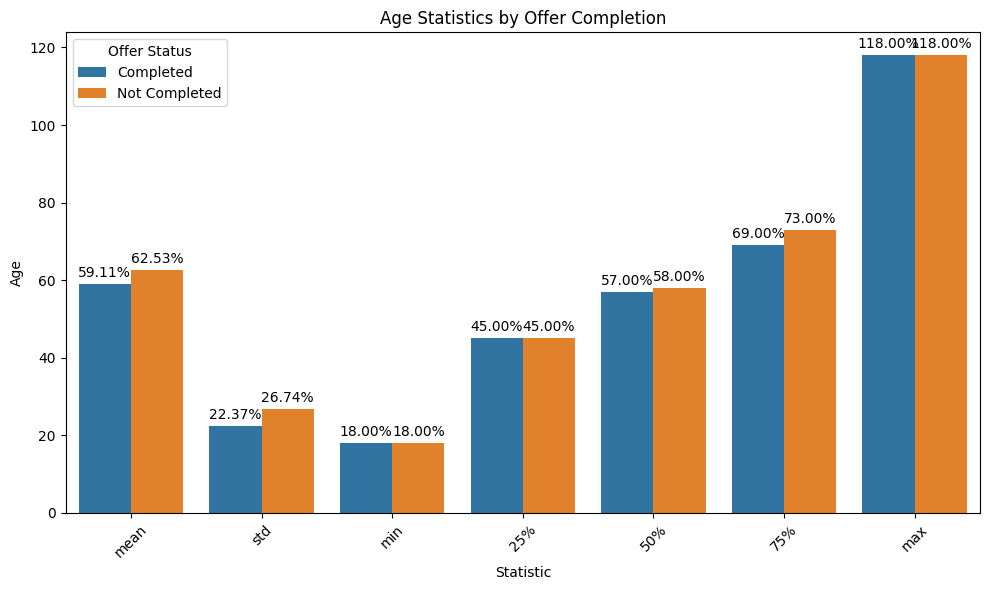

2025-06-17 11:49:08,579 - INFO - Starting analysis for average time to complete an offer...
2025-06-17 11:49:08,597 - INFO - Filtered valid offers IDs...DONE
2025-06-17 11:49:08,639 - INFO - Separating 'offer received' and 'offer completed' events...DONE
2025-06-17 11:49:08,640 - INFO - Renaming 'time' columns to 'received_time' and 'completed_time'...DONE
2025-06-17 11:49:08,693 - INFO - Grouped data by customer_id and offer_id...DONE
2025-06-17 11:49:08,713 - INFO - Merged dataFrame received_first with completed_first...DONE
2025-06-17 11:49:08,714 - INFO - Calculating time difference...DONE
2025-06-17 11:49:08,715 - INFO - Computing average time...DONE
2025-06-17 11:49:08,730 - INFO - effectiveness_channel.parquet exported
2025-06-17 11:49:08,731 - INFO - Exporting age_stats_df...DONE
2025-06-17 11:49:08,734 - INFO - Exporting df_avg_time...DONE
2025-06-17 11:49:08,735 - INFO - Every data exported sucessfully to ../output/!
2025-06-17 11:49:08,736 - INFO - Loading data into dataset 

Computed average time: 76.44 hours
Computed average time: 3.19 days.
Best channel: web with rate 87.50%


2025-06-17 11:49:12,909 - INFO - Successfully loaded 'df_avg_time.parquet' into 'data-pipeline-cafe.data_set_cafe.df_avg_time_table'.
2025-06-17 11:49:12,910 - INFO - Attempting to load 'effectiveness_channel.parquet' into table 'data-pipeline-cafe.data_set_cafe.effectiveness_table'...
2025-06-17 11:49:15,985 - INFO - Successfully loaded 'effectiveness_channel.parquet' into 'data-pipeline-cafe.data_set_cafe.effectiveness_table'.
2025-06-17 11:49:15,987 - INFO - Attempting to load 'age_stats_df.parquet' into table 'data-pipeline-cafe.data_set_cafe.age_stats_table'...
2025-06-17 11:49:19,255 - INFO - Successfully loaded 'age_stats_df.parquet' into 'data-pipeline-cafe.data_set_cafe.age_stats_table'.
2025-06-17 11:49:19,256 - INFO - Data load process to BigQuery completed.


In [10]:
def main():
    """
    Main function to execute the data extraction and analysis.
    """
    df_event, df_customer,  df_offer = extract_offer_id()
        
    dfs_total= merge_dfs(df_event, df_customer, df_offer)
    
    

    effectiveness_channel, most_effective, high_value_conclusion_rate = first_question(dfs_total)
    age_stats_df = second_question(dfs_total, df_customer)
    avg_time_hours, avg_time_days = last_question(dfs_total)

    df_avg_time = pd.DataFrame({
        'metric': ['avg_time_hours', 'avg_time_days'],
        'value': [avg_time_hours, avg_time_days]
    })
    df_avg_time['value'] = df_avg_time['value'].round(2)

    
    export_to_parquet(effectiveness_channel, most_effective, high_value_conclusion_rate, \
                age_stats_df, \
                df_avg_time,\
                "../output/")
    
    logging.info(f"Loading data into dataset '{DATASET_ID}'...")
    
    for table_name, file_path in parquet_files_to_load.items(): 
        load_to_bigquery(file_path, table_name, client, DATASET_ID, PROJECT_ID)

    logging.info("Data load process to BigQuery completed.")

if __name__ == "__main__":
  
    main()